<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB44·P7 · Puente (7): Álgebra lineal para robótica

**Puente de Python — Lección 7 de 7 (la última, antes del NB45)**

> En el NB14 aprendiste qué es una matriz y la operación estrella: **matriz por vector** (cada fila por el vector, con el producto escalar del NB13). Con eso se hace una capa de una red neuronal. Pero a partir del NB45, MuJoCo te va a hablar en un idioma más rico: la matriz de masas es "simétrica y **definida positiva**", el jacobiano "pierde **rango**", hay que usar la **pseudoinversa**, mirar los **valores singulares** y el **número de condición**...

Esta lección es el diccionario de ese idioma. Todo se construye sobre **una sola idea**, que lo hace todo mucho más fácil de imaginar: **una matriz es una transformación**, una máquina que mueve, gira, estira o aplasta el espacio. Cada concepto de hoy será una pregunta sobre esa máquina:

| Concepto | La pregunta |
|---|---|
| Matriz por matriz | ¿Qué pasa si aplico una máquina detrás de otra? |
| Inversa | ¿Puedo deshacer lo que hizo? |
| Determinante | ¿Cuánto agranda o encoge las áreas? |
| Rango | ¿Cuántas direcciones sobreviven? |
| Valores propios | ¿Qué direcciones solo se estiran, sin girar? |
| SVD | ¿En qué dirección estira más, y en cuál menos? |
| Número de condición | ¿Cuánto se amplifican los errores al deshacerla? |
| Pseudoinversa | ¿Y si no se puede deshacer del todo? |

Cada idea, como siempre, comprobada con NumPy. Trabajaremos casi todo en **2D** (matrices de 2×2), porque se puede **dibujar**; todo funciona igual en 3D y con matrices de cualquier tamaño.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)     # imprimir con 4 decimales, sin notación científica

(`np.set_printoptions` solo cambia cómo se **imprimen** los arrays, no sus valores: `suppress=True` escribe 0.0001 en vez de 1e-04.)

## 1 · Una matriz es una transformación

### Las columnas son adónde van los ejes

Toma la matriz

```
   A = | 2   1 |
       | 0   1 |
```

y multiplícala por los dos vectores más sencillos del plano: **e₁ = (1, 0)** (un paso a la derecha) y **e₂ = (0, 1)** (un paso hacia arriba). Por la regla del NB14 (cada fila por el vector):

- A·e₁ = (2·1 + 1·0, 0·1 + 1·0) = **(2, 0)**: la **primera columna** de A.
- A·e₂ = (2·0 + 1·1, 0·0 + 1·1) = **(1, 1)**: la **segunda columna** de A.

No es casualidad: multiplicar por e₁ "selecciona" la primera columna, y por e₂, la segunda. Y como cualquier vector es una mezcla de los dos, (x, y) = x·e₁ + y·e₂, la matriz lo lleva a la **misma mezcla de sus columnas**: A·(x, y) = x·(columna 1) + y·(columna 2).

> **Las columnas de una matriz dicen adónde van los ejes. Y sabiendo adónde van los ejes, sabes adónde va todo.**


In [2]:
A = np.array([[2.0, 1.0],
              [0.0, 1.0]])
e1, e2 = np.array([1.0, 0.0]), np.array([0.0, 1.0])
print("A @ e1 =", A @ e1, "| primera columna:", A[:, 0])
print("A @ e2 =", A @ e2, "| segunda columna:", A[:, 1])

A @ e1 = [2. 0.] | primera columna: [2. 0.]
A @ e2 = [1. 1.] | segunda columna: [1. 1.]


### Verlo

Una función para dibujar qué le hace una matriz a una figura: un cuadrado de lado 1 (con los ejes coloreados) y una "casita" con la chimenea a la derecha, para ver si algo se da la vuelta. La usaremos toda la lección:


In [3]:
cuadrado = np.array([[0, 1, 1, 0, 0],
                     [0, 0, 1, 1, 0]], dtype=float)          # sus esquinas, en columnas (2, 5)
casita = np.array([[0.2, 0.8, 0.8, 0.72, 0.72, 0.62, 0.62, 0.5, 0.2, 0.2],
                   [0.2, 0.2, 0.6, 0.68, 0.88, 0.88, 0.78, 0.9, 0.6, 0.2]])   # casita con chimenea a la derecha

def dibujar(matrices, titulos):
    fig, ejes = plt.subplots(1, len(matrices), figsize=(3.2 * len(matrices), 3.2))
    for ax, M, titulo in zip(np.atleast_1d(ejes), matrices, titulos):
        ax.plot(*(M @ cuadrado), color="gray")
        ax.fill(*(M @ casita), alpha=0.5)
        ax.arrow(0, 0, *M[:, 0], color="tab:red", width=0.03, length_includes_head=True)
        ax.arrow(0, 0, *M[:, 1], color="tab:green", width=0.03, length_includes_head=True)
        ax.set_xlim(-1.6, 3.2); ax.set_ylim(-1.6, 3.2)
        ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

(Las esquinas van en **columnas**, así que `M @ cuadrado` transforma las cinco a la vez: cada columna del resultado es M por una esquina. `*` delante de un array 2×5 lo reparte en sus dos filas, x e y, como argumentos de `plot`: desempaquetar, NB23. La flecha roja es adónde va e₁; la verde, adónde va e₂.)

Cinco máquinas típicas:


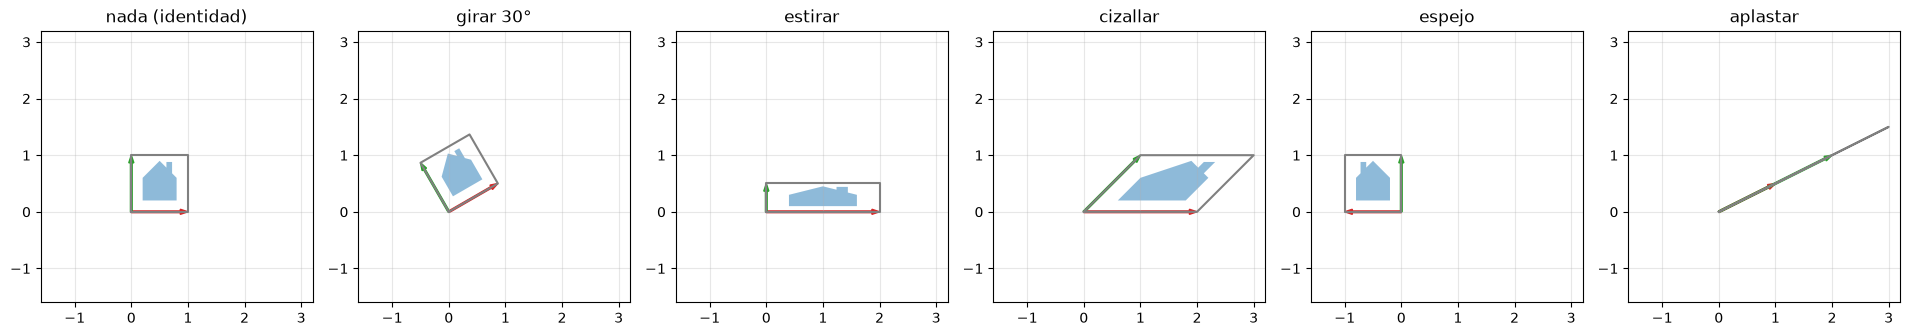

In [4]:
angulo = np.radians(30)
giro = np.array([[np.cos(angulo), -np.sin(angulo)],
                 [np.sin(angulo),  np.cos(angulo)]])
estirar = np.array([[2.0, 0.0], [0.0, 0.5]])
cizalla = A
espejo = np.array([[-1.0, 0.0], [0.0, 1.0]])
aplastar = np.array([[1.0, 2.0], [0.5, 1.0]])

dibujar([np.eye(2), giro, estirar, cizalla, espejo, aplastar],
        ["nada (identidad)", "girar 30°", "estirar", "cizallar", "espejo", "aplastar"])

- **Identidad**: no hace nada (la veremos ahora).
- **Giro** de 30°: la matriz de rotación del NB36 (sus columnas son los ejes girados, NB46).
- **Estirar**: el doble a lo ancho, la mitad a lo alto. Una matriz **diagonal** estira cada eje por separado.
- **Cizallar** (la A de antes): como empujar de lado un mazo de cartas.
- **Espejo**: da la vuelta a la izquierda y la derecha. ¡La chimenea ha pasado a la **izquierda**: la casita sale **al revés**!
- **Aplastar**: las dos columnas apuntan en la **misma dirección** (la segunda es el doble de la primera), así que todo el plano acaba **sobre una línea**. El cuadrado se ha quedado sin área.

Quédate con estas seis imágenes: cada concepto de hoy se entiende mirándolas.


## 2 · Matriz por matriz: una máquina detrás de otra

Si aplicas primero B a un vector y luego A al resultado, A·(B·x), el efecto total es **otra** transformación. ¿Qué matriz es? Sus columnas son adónde van los ejes: la columna j es A·(columna j de B). A esa matriz se la llama **producto A·B**:

```
   (A·B)·x  =  A·(B·x)          "primero B, luego A": se lee de DERECHA a IZQUIERDA
```

La regla para calcularlo: la casilla (i, j) de A·B es **la fila i de A por la columna j de B** (producto escalar). En NumPy, `A @ B` (lo usaste en el NB46 para componer giros).


In [5]:
x = np.array([1.0, 2.0])
print("A @ (giro @ x) =", A @ (giro @ x))
print("(A @ giro) @ x =", (A @ giro) @ x)

A @ (giro @ x) = [1.9641 2.2321]
(A @ giro) @ x = [1.9641 2.2321]


Lo mismo: componer y luego aplicar = aplicar uno detrás de otro.

### El orden importa

Con números, 2·3 = 3·2. Con matrices, **casi nunca**: A·B ≠ B·A. "Girar y luego estirar" no es lo mismo que "estirar y luego girar":


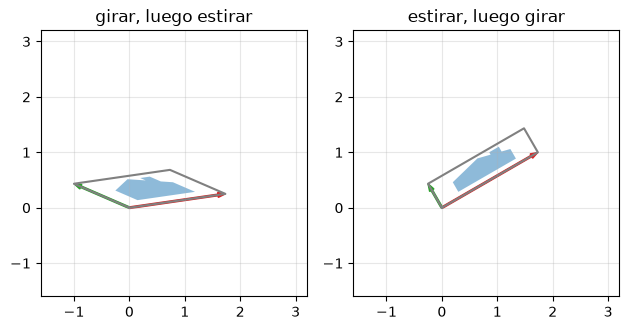

¿iguales? False


In [6]:
dibujar([estirar @ giro, giro @ estirar], ["girar, luego estirar", "estirar, luego girar"])
print("¿iguales?", np.allclose(estirar @ giro, giro @ estirar))

Dos figuras distintas. En el NB46 verás que esto, con giros 3D, es la raíz de casi todas las complicaciones de las orientaciones. Se dice que el producto de matrices **no conmuta**.

### La regla de los tamaños

Con matrices no cuadradas: A·B solo existe si A tiene **tantas columnas como filas tiene B** (cada fila de A tiene que poder multiplicarse por cada columna de B). Una (m × n) por una (n × p) da una (m × p): los dos números de "dentro" se tienen que tocar y desaparecen. Un jacobiano de 3×9 (NB46) por un vector de 9 velocidades da 3 números: la velocidad del pie.


## 3 · La identidad y la traspuesta

### La identidad: el 1 de las matrices

La matriz con **unos en la diagonal** y ceros en el resto deja cada eje donde estaba: no hace nada. Se llama **identidad**, se escribe **I**, y es el "1" de las matrices: I·A = A·I = A. En NumPy, `np.eye(n)` (de la pronunciación en inglés de la I, *eye*).


In [7]:
I = np.eye(2)
print(I)
print("I @ A == A:", np.allclose(I @ A, A), "| A @ I == A:", np.allclose(A @ I, A))

[[1. 0.]
 [0. 1.]]
I @ A == A: True | A @ I == A: True


### La traspuesta: filas por columnas

La **traspuesta** de una matriz, **Aᵀ**, se obtiene intercambiando filas y columnas: la fila 1 pasa a ser la columna 1. Una matriz de 2×3 traspuesta es de 3×2. En NumPy, `A.T`:


In [8]:
B = np.array([[1, 2, 3],
              [4, 5, 6]])
print(B, B.shape)
print(B.T, B.T.shape)

[[1 2 3]
 [4 5 6]] (2, 3)
[[1 4]
 [2 5]
 [3 6]] (3, 2)


¿Para qué sirve? Tres usos que verás constantemente:

1. **El producto escalar como producto de matrices.** Si piensas en los vectores como columnas (matrices de n × 1), el producto escalar de x e y es **xᵀ·y**: una fila (1 × n) por una columna (n × 1) da un número (1 × 1). Es así como lo escriben todos los libros.
2. **Matrices simétricas**: las que son iguales a su traspuesta, **A = Aᵀ** (la casilla (i, j) igual a la (j, i), un espejo respecto a la diagonal). La matriz de masas del NB45 lo es. Las simétricas tienen propiedades especiales que veremos en el apartado 8.
3. **Dar la vuelta a un producto**: (A·B)ᵀ = Bᵀ·Aᵀ (traspuesta de un producto = producto de las traspuestas **en orden contrario**). Un detalle que aparece al manipular fórmulas del NB46, como τ = Jᵀ·f.


In [9]:
x, y = np.array([1.0, 2.0, 3.0]), np.array([4.0, 5.0, 6.0])
print("x @ y =", x @ y, "| como matrices, xᵀ·y =", x.reshape(3, 1).T @ y.reshape(3, 1))

S = np.array([[2.0, 1.0], [1.0, 3.0]])
print("¿S simétrica?", np.allclose(S, S.T), "| ¿A simétrica?", np.allclose(A, A.T))
print("(A·B)ᵀ = Bᵀ·Aᵀ:", np.allclose((A @ B).T, B.T @ A.T))

x @ y = 32.0 | como matrices, xᵀ·y = [[32.]]
¿S simétrica? True | ¿A simétrica? False
(A·B)ᵀ = Bᵀ·Aᵀ: True


(Con vectores 1D de NumPy, `x @ y` ya es el producto escalar y `x.T` no hace nada: un array 1D no tiene "filas ni columnas". Para tener una columna de verdad hay que darle forma (3, 1), como en el `reshape`.)

## 4 · La inversa: deshacer

Si una matriz es una máquina, su **inversa** A⁻¹ es la máquina que **deshace** lo que hizo: A⁻¹·(A·x) = x. Es decir, **A⁻¹·A = I**.

- El giro de 30° se deshace girando −30°. (Para los giros, la inversa es la **traspuesta**, NB46: deshacer un giro sale gratis.)
- Estirar el doble se deshace encogiendo a la mitad.
- El espejo se deshace... con otro espejo: es su propia inversa.
- ¿Y **aplastar**? Todo el plano acaba sobre una línea. Muchos puntos distintos acaban en el **mismo** punto de la línea: ¿a cuál de ellos lo devuelves? Es imposible saberlo. **Una matriz que aplasta no tiene inversa.** Se llama **singular**.

### La inversa de una 2×2

Para 2×2 hay una fórmula corta (compruébala multiplicando, ejercicio E2):

```
   | a  b |⁻¹        1       |  d  −b |
   | c  d |    =  ───────  · | −c   a |          (intercambia a y d, cambia de signo b y c, divide entre a·d − b·c)
                  a·d − b·c
```

Ese número de abajo, a·d − b·c, es tan importante que tiene nombre propio: el **determinante** (apartado 6). Si vale **0**, hay que dividir entre 0: no hay inversa. Comprobémoslo con NumPy (`np.linalg.inv`):


In [10]:
A_inv = np.linalg.inv(A)
print("inversa de A:\n", A_inv)
print("A⁻¹·A =\n", A_inv @ A)
print("fórmula:\n", np.array([[1.0, -1.0], [0.0, 2.0]]) / (2 * 1 - 1 * 0))

inversa de A:
 [[ 0.5 -0.5]
 [ 0.   1. ]]
A⁻¹·A =
 [[1. 0.]
 [0. 1.]]
fórmula:
 [[ 0.5 -0.5]
 [ 0.   1. ]]


Y con la que aplasta (NumPy lanza un error, que capturamos con `try`, NB22):

In [11]:
try:
    np.linalg.inv(aplastar)
except np.linalg.LinAlgError as error:
    print("No se puede:", error)

No se puede: Singular matrix


**Singular matrix**: la matriz es singular, sin inversa.

(En el P6 viste que, para **resolver ecuaciones**, no hay que calcular la inversa, sino usar `solve`. La inversa es una idea fundamental, pero en el código casi nunca se calcula entera.)


## 5 · Resolver A·x = b

### Dos ecuaciones, dos incógnitas

Un problema típico de robótica: "¿qué velocidades de articulación dan **esta** velocidad del pie?" (NB46). Con números pequeños, es como esto:

```
   2·x + 1·y = 5
   0·x + 1·y = 1
```

Escrito con matrices: **A·x = b**, con A la de siempre, x = (x, y) las incógnitas y b = (5, 1). La pregunta es "¿qué vector, transformado por A, da b?": **deshacer** A sobre b. A mano: la segunda dice y = 1; metiéndolo en la primera, 2·x + 1 = 5, x = 2 (NB04b). Con NumPy, `np.linalg.solve(A, b)`:


In [12]:
b = np.array([5.0, 1.0])
solucion = np.linalg.solve(A, b)
print("x =", solucion, "| comprobación A·x =", A @ solucion)

x = [2. 1.] | comprobación A·x = [5. 1.]


### Una, ninguna o infinitas

Cada ecuación de dos incógnitas es una **recta** en el plano (NB04b): los puntos (x, y) que la cumplen. Resolver dos ecuaciones a la vez es buscar el punto que está **en las dos rectas**: donde se cortan. Y dos rectas pueden:

- **cortarse en un punto** → **una** solución (la matriz tiene inversa);
- ser **paralelas** → **ninguna** solución (nunca se cortan);
- ser **la misma recta** → **infinitas** soluciones (todos sus puntos valen).

Los dos últimos casos son, justo, los de una matriz singular: sus filas son "la misma ecuación" (multiplicada por algo), y o no cuadran o sobran. Con la de aplastar, x + 2y = 1 y 0,5x + y = 1 son paralelas (la segunda, por 2, sería x + 2y = 2: no puede ser a la vez 1 y 2).


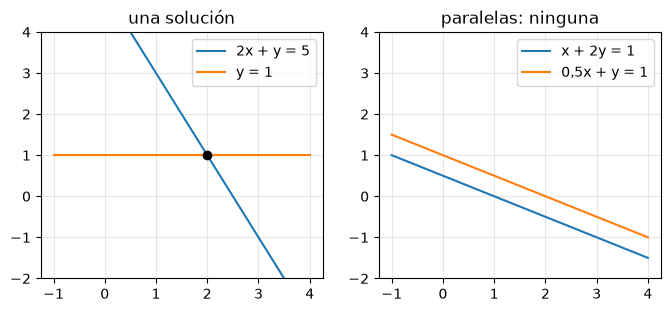

In [13]:
xs = np.linspace(-1, 4, 50)
fig, ejes = plt.subplots(1, 2, figsize=(8, 3.2))
ejes[0].plot(xs, 5 - 2 * xs, label="2x + y = 5")
ejes[0].plot(xs, np.ones_like(xs), label="y = 1")
ejes[0].plot(*solucion, "ko")
ejes[0].set_title("una solución")
ejes[1].plot(xs, (1 - xs) / 2, label="x + 2y = 1")
ejes[1].plot(xs, (1 - 0.5 * xs) / 1, label="0,5x + y = 1")
ejes[1].set_title("paralelas: ninguna")
for ax in ejes:
    ax.set_ylim(-2, 4); ax.grid(alpha=0.3); ax.legend()
plt.show()

## 6 · El determinante: cuánto escala las áreas

### La idea

Mira otra vez las seis figuras del apartado 1. El cuadrado gris tenía área 1. Después de cada máquina:

- girar: área **1** (un giro no agranda nada);
- estirar (×2 a lo ancho, ×0,5 a lo alto): área 2 × 0,5 = **1**;
- cizallar: un paralelogramo de base 2 y altura 1: área **2**;
- espejo: área 1... pero **dada la vuelta**;
- aplastar: área **0**.

El **determinante** de una matriz, det(A), es exactamente eso: **por cuánto multiplica las áreas** (en 3D, los volúmenes). Y su **signo** dice si da la vuelta a las figuras: **negativo = espejo**. Para una 2×2, es el a·d − b·c de la inversa. En NumPy, `np.linalg.det`:


In [14]:
for nombre, M in [("girar", giro), ("estirar", estirar), ("cizallar", cizalla),
                  ("espejo", espejo), ("aplastar", aplastar)]:
    print(f"{nombre:>9}: det = {np.linalg.det(M):+.3f}")

    girar: det = +1.000
  estirar: det = +1.000
 cizallar: det = +2.000
   espejo: det = -1.000
 aplastar: det = +0.000


Exactamente las áreas que habíamos calculado mirando, con el espejo en **negativo**. Tres reglas para recordar:

1. **det = 0 ⇔ aplasta ⇔ no tiene inversa** (singular). Es la forma más rápida de saber si una matriz se puede deshacer... en teoría (en la práctica, el apartado 10 da una herramienta mejor).
2. **Los giros tienen det = +1**: no cambian el tamaño ni dan la vuelta (NB46 lo comprueba con las rotaciones de MuJoCo).
3. **det(A·B) = det(A)·det(B)**: si una máquina duplica el área y la otra la triplica, juntas la multiplican por 6.

En el NB46, cuando la rodilla de Zancudo se estira del todo, el determinante de su jacobiano se hace **cero**: la pierna "aplasta" las velocidades de las articulaciones sobre una sola dirección. Es una **singularidad**.


## 7 · El rango y las matrices no cuadradas

### Cuántas direcciones sobreviven

La matriz de aplastar convierte el plano entero (2 dimensiones) en una línea (1 dimensión). Ha "perdido" una dirección. Al número de dimensiones que **sobreviven** se le llama **rango**. Es lo mismo que el número de columnas "de verdad distintas" (que no son mezclas de las demás): en la de aplastar, la segunda columna es el doble de la primera, así que solo hay **una** dirección de verdad.

- Una matriz de 2×2 normal tiene rango **2**: llena el plano.
- La de aplastar, rango **1**.
- La matriz de ceros, rango **0**: lo manda todo al origen.

En NumPy, `np.linalg.matrix_rank`:


In [15]:
for nombre, M in [("cizallar", cizalla), ("aplastar", aplastar), ("ceros", np.zeros((2, 2)))]:
    print(f"{nombre:>9}: rango {np.linalg.matrix_rank(M)}")

 cizallar: rango 2
 aplastar: rango 1
    ceros: rango 0


### Matrices que no son cuadradas

El determinante solo existe para matrices **cuadradas**. Pero el rango, para todas. Y en robótica, las matrices no cuadradas son lo normal:

- El **jacobiano** de un pie de Zancudo (NB46) es de **3×9**: entran 9 velocidades de articulación, salen 3 velocidades del pie. Tiene más columnas que filas: **muchas formas distintas** de mover las articulaciones dan la misma velocidad del pie. (El rango, como mucho, 3: no puede haber más direcciones que filas.)
- Un **ajuste por mínimos cuadrados** (NB30) usa matrices **altas**: muchas más ecuaciones (datos) que incógnitas (pesos). No hay solución exacta; hay que buscar la **mejor**.

Para esas dos situaciones existe la **pseudoinversa** (apartado 11). Antes, dos herramientas para mirar "dentro" de una matriz.


In [16]:
J = np.array([[1.0, 0.5, 0.2],
              [0.0, 1.0, 0.3]])          # un "jacobiano" de juguete: 3 articulaciones, 2 salidas
print("forma:", J.shape, "| rango:", np.linalg.matrix_rank(J))

forma: (2, 3) | rango: 2


## 8 · Valores y vectores propios: direcciones que solo se estiran

### La idea

Casi todas las flechas cambian de **dirección** al pasar por una matriz. Pero algunas matrices tienen direcciones **especiales** en las que la flecha sale en la **misma dirección** (o justo la contraria): solo se **estira** o se encoge. A esas direcciones se las llama **vectores propios**, y a cuánto se estiran, **valores propios**:

```
   A · v  =  λ · v            (v: vector propio; λ, "lambda": su valor propio)
```

En la matriz de estirar es obvio: e₁ se estira ×2 (vector propio con λ = 2) y e₂, ×0,5 (λ = 0,5). En la de cizallar, e₁ = (1, 0) va a (2, 0): misma dirección, ×2. ¿Hay más? NumPy los calcula con `np.linalg.eig` (los vectores propios salen en las **columnas**):


In [17]:
valores, vectores = np.linalg.eig(cizalla)
valores, vectores = valores.real, vectores.real          # (ver la nota de abajo)
print("valores propios:", valores)
print("vectores propios (en columnas):\n", vectores)
for i in range(2):
    v = vectores[:, i]
    print(f"A·v = {cizalla @ v}  |  λ·v = {valores[i] * v}")

valores propios: [2. 1.]
vectores propios (en columnas):
 [[ 1.     -0.7071]
 [ 0.      0.7071]]
A·v = [2. 0.]  |  λ·v = [2. 0.]
A·v = [-0.7071  0.7071]  |  λ·v = [-0.7071  0.7071]


Dos direcciones especiales: (1, 0), que se estira ×2, y (−0,707, 0,707) (la diagonal "hacia arriba a la izquierda"), que se queda igual (×1). Cualquier otra flecha cambia de dirección.

(Los vectores propios salen con longitud 1, y su signo es arbitrario: −v es tan propio como v. Y la nota: `eig` puede devolverlos como números **complejos**, una clase de números que no necesitamos, por si la matriz los tuviera de ese tipo; aquí son reales normales, y `.real` se queda con ellos.)

### Las simétricas: las más agradables

Las matrices **simétricas** (como la de masas del NB45) tienen dos propiedades que las hacen especialmente fáciles:

1. Sus valores propios son siempre números **reales** (las no simétricas, como un giro, pueden tenerlos "complejos": un giro de 30° no deja **ninguna** dirección quieta).
2. Sus vectores propios son **perpendiculares** entre sí. Una matriz simétrica es siempre "estirar a lo largo de unos ejes perpendiculares", solo que esos ejes pueden estar inclinados.

Para simétricas se usa `np.linalg.eigh` (más rápida y precisa, y ordena los valores de menor a mayor; `eigvalsh` da solo los valores, como en el NB45):


In [18]:
valores, vectores = np.linalg.eigh(S)
print("valores propios de S:", valores)
print("¿vectores perpendiculares?", np.isclose(vectores[:, 0] @ vectores[:, 1], 0))

valores propios de S: [1.382 3.618]
¿vectores perpendiculares? True


### Definida positiva

Una matriz simétrica es **definida positiva** si **todos sus valores propios son positivos**. Significa que estira (más o menos) en todas sus direcciones especiales, pero no aplasta ninguna (λ = 0) ni da la vuelta a ninguna (λ < 0).

¿Por qué le importa a un robot? Por la **energía cinética** (NB38b). Para un robot con muchas articulaciones, la energía cinética se escribe con la matriz de masas M y el vector de velocidades q̇ como:

```
   energía cinética  =  ½ · q̇ᵀ · M · q̇
```

(La gemela de ½·m·v², con matrices.) Una matriz definida positiva es, justo, una que cumple **xᵀ·M·x > 0 para cualquier x que no sea cero**. Es decir: **si el robot se mueve, de la forma que sea, tiene energía cinética positiva**. Física razonable. Y gracias a eso, M siempre tiene inversa (ningún λ es 0: no aplasta), y la ecuación del movimiento siempre tiene solución (NB45).

Comprobémoslo con S (valores propios 1,38 y 3,62, los dos positivos) y con mil vectores al azar:


In [19]:
generador = np.random.default_rng(0)
xs = generador.standard_normal((1000, 2))            # mil vectores al azar, en filas
energias = np.einsum("ni,ij,nj->n", xs, S, xs)       # xᵀ·S·x para cada uno
print("la más pequeña:", energias.min().round(4), "→ ¿todas positivas?", (energias > 0).all())

la más pequeña: 0.0014 → ¿todas positivas? True


(`np.einsum` del P6: para cada fila n, suma x_i · S_ij · x_j. Es xᵀ·S·x para los mil a la vez.)

Todas positivas. Con una simétrica que tenga un valor propio negativo, habría direcciones con "energía" negativa: físicamente imposible para una matriz de masas.


## 9 · SVD: el círculo se convierte en elipse

### Toda matriz es girar, estirar y girar

Las simétricas estiran a lo largo de ejes perpendiculares. ¿Y las demás? Un teorema precioso dice que **cualquier** matriz, cuadrada o no, se puede escribir como tres pasos:

```
   A  =  U · Σ · Vᵀ          1.º girar (Vᵀ)   2.º estirar cada eje (Σ, diagonal)   3.º girar (U)
```

Se llama **descomposición en valores singulares**, o **SVD** (*singular value decomposition*). Los números de la diagonal de Σ, siempre positivos o cero y ordenados de mayor a menor, son los **valores singulares** (σ, "sigma"): cuánto estira la matriz en su dirección **más fácil**, en la siguiente, y en la **más difícil**.

La forma de verlo: un **círculo** de radio 1, pasado por cualquier matriz, se convierte en una **elipse**. Los valores singulares son los **semiejes** de la elipse: el más largo y el más corto.


valores singulares: [2.2882 0.874 ]


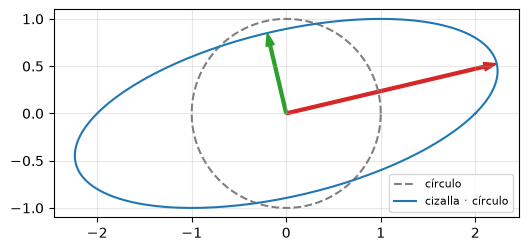

In [20]:
t = np.linspace(0, 2 * np.pi, 200)
circulo = np.array([np.cos(t), np.sin(t)])               # (2, 200): un círculo de radio 1
U, sigmas, Vt = np.linalg.svd(cizalla)
print("valores singulares:", sigmas)

elipse = cizalla @ circulo
plt.figure(figsize=(6, 3.5))
plt.plot(*circulo, "--", color="gray", label="círculo")
plt.plot(*elipse, label="cizalla · círculo")
for s, u, color in zip(sigmas, U.T, ["tab:red", "tab:green"]):
    plt.arrow(0, 0, *(s * u), color=color, width=0.03, length_includes_head=True)
plt.gca().set_aspect("equal"); plt.grid(alpha=0.3); plt.legend(loc="lower right", fontsize=8)
plt.show()

El círculo se ha convertido en una elipse inclinada. Su semieje largo (rojo) mide 2,29; el corto (verde), 0,87: los dos valores singulares. Las direcciones de los semiejes son las columnas de U.

Tres cosas que salen de aquí:

- **Producto de los valores singulares = |det|** (2,29 × 0,87 ≈ 2): el área de la elipse comparada con la del círculo.
- **Un valor singular 0 = aplastar**: la elipse se convierte en un segmento. El número de valores singulares que no son cero es el **rango**. Así lo calcula `matrix_rank` por dentro.
- La SVD funciona con matrices **no cuadradas**: para el jacobiano de 3×9 del NB46, los valores singulares dicen cuánto se mueve el pie (por radián de articulación) en su dirección más fácil y en la más difícil. Si el menor se acerca a 0, la pierna está cerca de una singularidad.


## 10 · El número de condición: cuánto se amplifican los errores

### Rectas casi paralelas

Volvamos a A·x = b. Si las dos rectas se cortan **de frente**, un pequeño error en b (un sensor con ruido, NB41) mueve un poco el punto de corte. Pero si son **casi paralelas**, moverlas un pelín desplaza el corte **muchísimo**. Probémoslo con dos ecuaciones casi iguales:

```
   x +       y = 2
   x + 1,001·y = 2,001          → solución: x = 1, y = 1
```


In [21]:
casi_paralelas = np.array([[1.0, 1.0],
                           [1.0, 1.001]])
b = np.array([2.0, 2.001])
print("solución:", np.linalg.solve(casi_paralelas, b))
b_con_ruido = b + np.array([0.0, 0.001])                 # un error de una milésima
print("con un error de 0,001 en b:", np.linalg.solve(casi_paralelas, b_con_ruido))

solución: [1. 1.]
con un error de 0,001 en b: [0. 2.]


Un error de **una milésima** en b ha cambiado la solución de (1, 1) a (0, 2): un error de **1** en x. ¡Mil veces más grande!

### El número de condición

¿Cuánto puede amplificar una matriz los errores al resolver con ella? Lo dice el **número de condición**:

```
   número de condición  =  valor singular mayor  ÷  valor singular menor
```

Una elipse muy **alargada** (un semieje enorme y otro diminuto) significa que la matriz "casi aplasta" una dirección, y deshacerla en esa dirección exige **multiplicar** por un número enorme: también los errores. Un número de condición de 1 (un círculo, como un giro) es perfecto; de 1.000, los errores pueden crecer mil veces; infinito, singular. En NumPy, `np.linalg.cond`:


In [22]:
for nombre, M in [("girar", giro), ("cizallar", cizalla), ("casi paralelas", casi_paralelas)]:
    print(f"{nombre:>14}: condición {np.linalg.cond(M):10.1f}")

         girar: condición        1.0
      cizallar: condición        2.6
casi paralelas: condición     4002.0


La de las rectas casi paralelas: **4.000**. Por eso un error de 10⁻³ produjo un error del orden de 1.

Esta es la herramienta buena para decir "casi singular". El determinante **no** sirve para eso: la matriz 0,01·I (encoge todo a la centésima) tiene determinante 0,0001, diminuto, pero se deshace perfectamente (condición 1). En el NB46 verás el número de condición del jacobiano de la pierna dispararse cuando la rodilla se estira, y en el P6 viste qué le pasa a `inv` con una matriz de condición 10¹³.


## 11 · La pseudoinversa: deshacer lo que se pueda

¿Qué hacemos cuando A·x = b no tiene **exactamente una** solución? Las dos situaciones del apartado 7:

### Demasiadas ecuaciones: la mejor aproximación

Tienes 5 mediciones (con ruido) de un sensor, y quieres la recta y = m·x + c que mejor pasa por ellas: 5 ecuaciones, 2 incógnitas (m y c). Ninguna recta pasa por los 5 puntos a la vez: **no hay solución exacta**. Pero hay una **mejor**: la que hace más pequeña la suma de los errores al cuadrado. Son los **mínimos cuadrados** del NB30 (`lstsq`), y la **pseudoinversa** A⁺ (`np.linalg.pinv`) da exactamente esa solución: x = A⁺·b.


In [23]:
x_medido = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_medido = np.array([1.1, 2.9, 5.2, 6.8, 9.1])            # más o menos y = 2x + 1, con ruido
A_alta = np.column_stack([x_medido, np.ones(5)])         # cada fila: [x, 1] → m·x + c·1
print("forma:", A_alta.shape)
m, c = np.linalg.pinv(A_alta) @ y_medido
print(f"mejor recta: y = {m:.3f}·x {c:+.3f}")
print("lstsq da lo mismo:", np.linalg.lstsq(A_alta, y_medido, rcond=None)[0])

forma: (5, 2)
mejor recta: y = 1.990·x +1.040
lstsq da lo mismo: [1.99 1.04]


(`np.column_stack` pone vectores como columnas de una matriz: la de las x y una de unos, para el término c.)

Muy cerca de la recta "de verdad", y = 2x + 1. La pseudoinversa "deshace" A lo mejor que se puede.

### Pocas ecuaciones: la solución más pequeña

El caso contrario: el jacobiano de juguete del apartado 7 (2 salidas, 3 articulaciones). Quiero una velocidad del pie concreta, b = (1, 0,5). Hay **infinitas** combinaciones de las 3 articulaciones que la consiguen. ¿Cuál elijo? La pseudoinversa elige la **más pequeña** (la de menor longitud): moverse lo **mínimo** para conseguirlo. Una elección muy razonable para un robot.


In [24]:
b_pie = np.array([1.0, 0.5])
velocidades = np.linalg.pinv(J) @ b_pie
print("velocidades de las articulaciones:", velocidades, "| longitud:", np.linalg.norm(velocidades).round(4))
print("¿consigue la del pie? J·q̇ =", J @ velocidades)

otra = velocidades + np.array([-0.1, -0.6, 2.0])          # sumarle algo que J manda a cero
print("otra solución:", J @ otra, "| longitud:", np.linalg.norm(otra).round(4))

velocidades de las articulaciones: [0.7414 0.4485 0.1716] | longitud: 0.8834
¿consigue la del pie? J·q̇ = [1.  0.5]
otra solución: [1.  0.5] | longitud: 2.2694


Las dos consiguen exactamente la velocidad del pie pedida, pero la de la pseudoinversa es mucho más **corta**. (El vector que sumamos, (−0,1, −0,6, 2), es uno que J manda a cero: compruébalo, J·(−0,1, −0,6, 2) = (−0,1 − 0,3 + 0,4, −0,6 + 0,6) = (0, 0). Moverse en esa dirección no mueve el pie: es "movimiento sobrante". Se le llama el **espacio nulo** de J.)

En resumen, la **pseudoinversa**:

- si hay **una** solución exacta, es la inversa de siempre;
- si hay **ninguna**, da la **mejor aproximación** (mínimos cuadrados);
- si hay **infinitas**, da la **más pequeña**.

Por dentro, se calcula con la SVD: deshace los giros (trasponiéndolos) y divide entre cada valor singular... excepto los que son 0 (o casi), que deja en 0 en vez de dividir entre 0. Justo ahí está su punto débil, y por eso el NB46 usará una versión "amortiguada".


## 12 · El producto vectorial

La última herramienta es distinta: no es de matrices, sino de vectores en **3D**. Ya la usaste en el P6 para calcular un par (`np.cross`). Hoy, qué es.

### La definición

El **producto vectorial** de dos vectores a y b de 3D, **a × b**, es **otro vector** que:

1. es **perpendicular** a los dos;
2. mide **|a| · |b| · sen(ángulo entre ellos)**: máximo si son perpendiculares, 0 si son paralelos;
3. apunta hacia el lado que dice la **regla de la mano derecha**: con la mano derecha, el índice en la dirección de a, el corazón en la de b, y el pulgar señala a × b.

(Compáralo con el producto escalar del NB13, que da un **número** y mide con el **coseno**: lo que se parecen las direcciones. El vectorial mide con el **seno**: lo que **no** se parecen.)

Con componentes, la fórmula es:

```
   a × b  =  ( a_y·b_z − a_z·b_y ,   a_z·b_x − a_x·b_z ,   a_x·b_y − a_y·b_x )
```


In [25]:
ex, ey, ez = np.eye(3)                                   # los tres ejes
print("x × y =", np.cross(ex, ey), "(el eje z: mano derecha)")
print("y × x =", np.cross(ey, ex), "(¡al revés!)")
print("x × x =", np.cross(ex, ex), "(paralelos: cero)")

x × y = [0. 0. 1.] (el eje z: mano derecha)
y × x = [ 0.  0. -1.] (¡al revés!)
x × x = [0. 0. 0.] (paralelos: cero)


El orden importa: **b × a = −(a × b)**. Y un vector por sí mismo da 0.

### Para qué sirve en robótica

- **El par de una fuerza** (NB37): **τ = r × F**, con r el brazo (de la articulación al punto donde se empuja) y F la fuerza. Su módulo es |r|·|F|·sen(ángulo): la fuerza solo hace girar con su parte perpendicular al brazo (la llave inglesa del NB37). Su **dirección** es el **eje** alrededor del cual hace girar.
- **La velocidad de un punto que gira**: si un cuerpo gira con velocidad angular **ω** (un vector a lo largo del eje de giro, con módulo los rad/s), un punto a una distancia r del eje se mueve a **v = ω × r** (NB36: v = r·ω, ahora con dirección).
- **Normales**: el vector perpendicular a una superficie (para los contactos del NB48) es el producto vectorial de dos vectores de la superficie.


In [26]:
r = np.array([0.0, 0.0, 0.4])               # brazo de 40 cm hacia arriba
F = np.array([10.0, 0.0, 0.0])              # 10 N horizontales
F_inclinada = np.array([10.0, 0.0, 10.0])   # la misma, pero inclinada 45° (más larga: 14,1 N)
print("τ = r × F:", np.cross(r, F), "N·m")
print("con la fuerza inclinada:", np.cross(r, F_inclinada), "N·m (solo cuenta la parte perpendicular)")

omega = np.array([0.0, 0.0, 2.0])           # gira a 2 rad/s alrededor del eje z
punto = np.array([0.5, 0.0, 0.0])           # a 0,5 m del eje
print("v = ω × r:", np.cross(omega, punto), "m/s (2 × 0,5 = 1 m/s, tangente al círculo)")

τ = r × F: [0. 4. 0.] N·m
con la fuerza inclinada: [0. 4. 0.] N·m (solo cuenta la parte perpendicular)
v = ω × r: [0. 1. 0.] m/s (2 × 0,5 = 1 m/s, tangente al círculo)


El par sale 4 N·m alrededor del eje y, también con la fuerza inclinada: su parte a lo largo del brazo (la vertical) no hace girar. Y el punto que gira se mueve a 1 m/s en dirección y: perpendicular al radio, como el punto del círculo del NB39b.


## 13 · Resumen (y cierre del puente)

1. **Una matriz es una transformación**: sus **columnas** son adónde van los ejes. Gira, estira, cizalla, refleja o aplasta.
2. **A·B** = primero B, luego A. Casilla (i, j) = fila i de A · columna j de B. **No conmuta.** (m×n)·(n×p) = (m×p).
3. **Identidad** I (`np.eye`): no hace nada. **Traspuesta** Aᵀ (`.T`): filas por columnas; xᵀ·y = producto escalar; **simétrica** si A = Aᵀ; (A·B)ᵀ = Bᵀ·Aᵀ.
4. **Inversa** A⁻¹: deshace (A⁻¹·A = I). 2×2: intercambiar, cambiar signos, dividir entre a·d − b·c. Si aplasta, no existe: **singular**. Para resolver, `solve`, no `inv`.
5. **A·x = b**: rectas que se cortan: una solución, ninguna (paralelas) o infinitas (la misma).
6. **Determinante**: por cuánto multiplica áreas (volúmenes); negativo = espejo; **0 = singular**. Giros: +1. det(A·B) = det(A)·det(B).
7. **Rango**: cuántas direcciones sobreviven. Las matrices no cuadradas (jacobianos, datos) son lo normal.
8. **Valores/vectores propios**: A·v = λ·v, direcciones que solo se estiran. Simétricas: λ reales, vectores perpendiculares. **Definida positiva**: todos los λ > 0 ⇔ xᵀ·A·x > 0; la matriz de masas (energía ½·q̇ᵀ·M·q̇).
9. **SVD**: A = U·Σ·Vᵀ (girar, estirar, girar); el círculo → elipse; **valores singulares** = semiejes. Su número no nulo = rango.
10. **Número de condición** = σ mayor / σ menor: cuánto se amplifican los errores. La buena medida de "casi singular" (el determinante no lo es).
11. **Pseudoinversa** (`pinv`): una solución → la inversa; ninguna → mínimos cuadrados; infinitas → la más pequeña. **Espacio nulo**: lo que A manda a cero.
12. **Producto vectorial** a × b: perpendicular, |a|·|b|·sen, mano derecha, b × a = −a × b. **τ = r × F**, **v = ω × r**.

Con esta lección termina el **puente**. Has pasado del Python de principiante (NB05-NB27) al de un profesional (P1-P6), y del "matriz por vector" al álgebra lineal con la que se escribe la robótica. En el **NB45** abrimos MuJoCo por dentro: la ecuación del movimiento, M·q̈ + c = τ, con su matriz de masas simétrica y definida positiva. Ya sabes leer cada palabra.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Transformación lineal** | Lo que hace una matriz al espacio: girar, estirar, cizallar, reflejar, aplastar. |
| **Identidad (I)** | La matriz que no hace nada: unos en la diagonal. |
| **Traspuesta (Aᵀ)** | Intercambiar filas y columnas. |
| **Simétrica** | Igual a su traspuesta. |
| **Inversa (A⁻¹)** | La matriz que deshace A. |
| **Singular** | Sin inversa: aplasta alguna dirección. |
| **Determinante** | Por cuánto multiplica las áreas o volúmenes; negativo si refleja. |
| **Rango** | Cuántas dimensiones sobreviven a la transformación. |
| **Valor / vector propio** | A·v = λ·v: una dirección que solo se estira, y cuánto. |
| **Definida positiva** | Simétrica con todos los valores propios positivos: xᵀ·A·x > 0. |
| **SVD / valores singulares** | A = U·Σ·Vᵀ; los semiejes de la elipse en que se convierte un círculo. |
| **Número de condición** | σ mayor / σ menor: cuánto puede amplificar los errores. |
| **Pseudoinversa (A⁺)** | La "mejor inversa posible" para matrices singulares o no cuadradas. |
| **Mínimos cuadrados** | La solución que hace mínima la suma de los errores al cuadrado. |
| **Espacio nulo** | Los vectores que una matriz manda a cero. |
| **Producto vectorial (×)** | Vector perpendicular a otros dos, de módulo |a|·|b|·sen. |


## 14 · Ejercicios

**E1.** Sin ordenador: ¿qué hace la matriz [[0, −1], [1, 0]] al cuadrado? (Mira adónde van los ejes.) ¿Cuánto vale su determinante? ¿Y qué hace si la aplicas **cuatro** veces? Comprueba con NumPy.

**E2.** Comprueba la fórmula de la inversa de una 2×2 para A = [[3, 1], [2, 4]]: calcúlala a mano y multiplícala por A.

**E3.** Escribe una matriz de 2×2 que estire ×3 en la dirección de la diagonal (1, 1) y deje igual la dirección (1, −1). (Pista: tiene que ser simétrica; prueba [[a, b], [b, a]] y busca a y b con A·(1, 1) = 3·(1, 1) y A·(1, −1) = (1, −1).) Comprueba sus valores y vectores propios con `eigh`.

**E4.** Calcula el determinante de giro @ estirar @ espejo, sin calcular el producto, usando det(A·B) = det(A)·det(B). Compruébalo.

**E5.** ¿Es definida positiva [[1, 2], [2, 1]]? Busca un vector x con xᵀ·A·x < 0.

**E6.** Para la matriz de "casi paralelas" del apartado 10, calcula los valores singulares y comprueba que su cociente es el número de condición. Luego cambia 1,001 por 1,1: ¿cuánto vale ahora la condición? ¿Y el error en x con el mismo ruido de 0,001?

**E7.** Ajusta por mínimos cuadrados una **parábola** y = a·x² + b·x + c a los puntos (−2, 4,1), (−1, 1,2), (0, −0,1), (1, 0,8), (2, 4,2). (Pista: cada fila de la matriz es [x², x, 1].)

**E8.** Comprueba con NumPy que a × b es perpendicular a a y a b (productos escalares 0), y que su longitud es |a|·|b|·sen(ángulo), para a = (1, 2, 0) y b = (3, 0, 1). (El ángulo sale del producto escalar: cos = a·b / (|a|·|b|).)

---

### Soluciones

<details>
<summary>▶ Solución E1</summary>

e₁ = (1, 0) va a la primera columna, (0, 1): el eje x pasa a apuntar hacia arriba. e₂ = (0, 1) va a (−1, 0). Es un **giro de 90°** en sentido contrario a las agujas del reloj. Determinante: 0·0 − (−1)·1 = **1** (los giros, +1). Cuatro veces: 360°, la **identidad**.

```python
R90 = np.array([[0.0, -1.0], [1.0, 0.0]])
print(np.linalg.det(R90))
print(np.linalg.matrix_power(R90, 4))      # R90 @ R90 @ R90 @ R90
```
</details>

<details>
<summary>▶ Solución E2</summary>

a·d − b·c = 3·4 − 1·2 = 10. Inversa = (1/10)·[[4, −1], [−2, 3]] = [[0,4, −0,1], [−0,2, 0,3]].

```python
M = np.array([[3.0, 1.0], [2.0, 4.0]])
M_inv = np.array([[4.0, -1.0], [-2.0, 3.0]]) / 10
print(M_inv @ M)
print(np.allclose(M_inv, np.linalg.inv(M)))
```
</details>

<details>
<summary>▶ Solución E3</summary>

A·(1, 1) = (a + b, a + b) = (3, 3) → a + b = 3. A·(1, −1) = (a − b, b − a) = (1, −1) → a − b = 1. Sumando: 2a = 4, **a = 2, b = 1**. Es la matriz [[2, 1], [1, 2]].

```python
M = np.array([[2.0, 1.0], [1.0, 2.0]])
valores, vectores = np.linalg.eigh(M)
print(valores)          # [1, 3]
print(vectores)         # columnas: (1, −1)/√2 y (1, 1)/√2, quizá con el signo cambiado
```
</details>

<details>
<summary>▶ Solución E4</summary>

det(giro) · det(estirar) · det(espejo) = 1 · 1 · (−1) = **−1**: no cambia el área, pero da la vuelta.

```python
print(np.linalg.det(giro @ estirar @ espejo))
```
</details>

<details>
<summary>▶ Solución E5</summary>

**No**: sus valores propios son 3 y **−1**. El vector propio de −1 es (1, −1): xᵀ·A·x = 1 − 2 − 2 + 1 = **−2** < 0.

```python
M = np.array([[1.0, 2.0], [2.0, 1.0]])
print(np.linalg.eigvalsh(M))
x = np.array([1.0, -1.0])
print(x @ M @ x)
```
</details>

<details>
<summary>▶ Solución E6</summary>

```python
for d in [1.001, 1.1]:
    M = np.array([[1.0, 1.0], [1.0, d]])
    s = np.linalg.svd(M, compute_uv=False)
    b = np.array([2.0, 1.0 + d])                             # así la solución exacta es (1, 1)
    error = np.linalg.solve(M, b + np.array([0.0, 0.001])) - np.array([1.0, 1.0])
    print(f"d = {d}: σ = {s}, σ1/σ2 = {s[0] / s[1]:.1f}, cond = {np.linalg.cond(M):.1f}, "
          f"error en x = {np.abs(error).max():.4f}")
```

Con 1,1, la condición baja a unos **42** y el mismo ruido da un error de solo 0,01 en x (en vez de 1). Rectas que se cortan con más ángulo, solución más robusta.
</details>

<details>
<summary>▶ Solución E7</summary>

```python
xs = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
ys = np.array([4.1, 1.2, -0.1, 0.8, 4.2])
X = np.column_stack([xs ** 2, xs, np.ones(5)])
a, b, c = np.linalg.pinv(X) @ ys
print(f"y = {a:.3f}·x² {b:+.3f}·x {c:+.3f}")
```

Sale y = 1,057·x² − 0,020·x − 0,074: casi y = x². (Una parábola, ajustada con álgebra **lineal**: es lineal en las incógnitas a, b, c, aunque no lo sea en x.)
</details>

<details>
<summary>▶ Solución E8</summary>

```python
a, b = np.array([1.0, 2.0, 0.0]), np.array([3.0, 0.0, 1.0])
c = np.cross(a, b)
print("a × b =", c, "| a·c =", a @ c, "| b·c =", b @ c)
coseno = a @ b / (np.linalg.norm(a) * np.linalg.norm(b))
seno = np.sqrt(1 - coseno ** 2)                       # sen² + cos² = 1 (NB36)
print(np.linalg.norm(c), "≈", np.linalg.norm(a) * np.linalg.norm(b) * seno)
```
</details>


## 15 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Siguiente parada: el **NB45**, cómo piensa MuJoCo por dentro.
